In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import yfinance as yf
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import norm


## Functions 

In [2]:
def Pagan_test(data): 
    # Create DataFrame from data dictionary
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    # Drop rows with missing values to avoid errors during modeling
    df = df.dropna()

    # Build the formula string dynamically from your independent variables
    independent_vars = "+".join([f"X{i}" for i in range(1, len(df.columns))])
    formula = f"Y ~ {independent_vars}"

    # Fit the OLS regression model
    model = smf.ols(formula=formula, data=df).fit()

    # Run the Breusch-Pagan test
    bp_test = sms.het_breuschpagan(model.resid, model.model.exog)
    labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']

    # Print Breusch-Pagan test results
    for label, value in zip(labels, bp_test):
        print(f"{label}: {value}")

def Durbin_Watson_test(data, one_x=False):
    # Create DataFrame from data dictionary
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else:
        df = data

    # Drop rows with missing values to avoid errors during modeling
    df = df.dropna()

    # Build the formula string dynamically from your independent variables
    if not one_x: 
        independent_vars = "+".join([f"X{i}" for i in range(1, len(df.columns))])
        formula = f"Y ~ {independent_vars}"
    else:
        formula = "Y ~ X1"
    # Fit the OLS regression model
    model = smf.ols(formula=formula, data=df).fit()

    # Compute Durbin-Watson statistic
    dw_stat = durbin_watson(model.resid)

    # Approximate p-value using normal approximation on rho_hat
    n = len(model.resid)
    k = len(df.columns) - 1
    rho_hat = 1 - dw_stat / 2
    z_stat = rho_hat / np.sqrt(1 / (n - k))
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))

    labels = ['Durbin-Watson statistic', 'rho estimate', 'z-statistic', 'p-value']
    values = [dw_stat, rho_hat, z_stat, p_value]

    # Print Durbin-Watson test results
    for label, value in zip(labels, values):
        print(f"{label}: {value}")

def Cochrane_Orcutt_test(data):
    # Create DataFrame from data dictionary
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else:
        df = data

    # Drop rows with missing values
    df = df.dropna()

    # Build formula dynamically
    independent_vars = "+".join([f"X{i}" for i in range(1, len(df.columns))])
    formula = f"Y ~ {independent_vars}"

    # Step 1: Fit initial OLS model
    model = smf.ols(formula=formula, data=df).fit()

    # Step 2: Estimate rho from residuals
    residuals = model.resid
    rho = np.corrcoef(residuals[:-1], residuals[1:])[0, 1]

    # Step 3: Transform variables using rho
    df_transformed = df.copy()
    for col in df.columns:
        df_transformed[col] = df[col] - rho * df[col].shift(1)
    df_transformed = df_transformed.dropna()

    # Step 4: Refit OLS on transformed data
    model_co = smf.ols(formula=formula, data=df_transformed).fit()

    # Step 5: Compute DW on new residuals
    dw_stat = durbin_watson(model_co.resid)
    n = len(model_co.resid)
    k = len(df.columns) - 1
    rho_hat = 1 - dw_stat / 2
    z_stat = rho_hat / np.sqrt(1 / (n - k))
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))

    print(f"Estimated rho: {rho:.4f}")
    print(f"Adjusted R²: {model_co.rsquared_adj:.4f}")
    print(f"Durbin-Watson statistic: {dw_stat:.4f}")
    print(f"rho estimate: {rho_hat:.4f}")
    print(f"z-statistic: {z_stat:.4f}")
    print(f"p-value: {p_value:.4f}")

def robust_regression(data, cov_type='HC3'):
    """
    Fit OLS regression with robust standard errors (Huber-White)
    
    Parameters:
    -----------
    data : dict or DataFrame
        Data with 'Y' as dependent variable and 'X1', 'X2', etc. as independent variables
    cov_type : str, default 'HC3'
        Type of robust covariance matrix ('HC0', 'HC1', 'HC2', 'HC3')
        HC3 is recommended for most cases
    
    Returns:
    --------
    Fitted regression model with robust standard errors
    """
    # Create DataFrame from data dictionary
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df = data

    # Drop rows with missing values to avoid errors during modeling
    df = df.dropna()

    # Build the formula string dynamically from your independent variables
    independent_vars = "+".join([f"X{i}" for i in range(1, len(df.columns))])
    formula = f"Y ~ {independent_vars}"

    # Fit the OLS regression model with robust standard errors
    model = smf.ols(formula=formula, data=df).fit(cov_type=cov_type)

    # Print summary
    print(model.summary())
    
    return model

def Whites_test(data):
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    X = df[[f'X{i}' for i in range(1, len(df.columns))]]
    X = sm.add_constant(X)
    y = df['Y']

    model = sm.OLS(y, X).fit()

    white_test = sms.het_white(model.resid, model.model.exog)

    labels = ['Test Statistic', 'Test Statistic p-value', 'F-Statistic', 'F-Test p-value']
    for label, value in zip(labels, white_test):
        print(f"{label}: {value}")

def p_valueTest(data):

    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    # Assume df is your DataFrame with independent variables X1, X2,... and dependent variable Y
    X = df.drop('Y', axis=1)
    y = df['Y']

    # Add a constant to the model (intercept)
    X = sm.add_constant(X)

    # Fit the model
    model = sm.OLS(y, X).fit()

    # Get summary which includes p-values
    print(model.summary())

    # Or just get the p-values directly:
    p_values = model.pvalues
    print(p_values)

def LRM(data): 

    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":

        df = pd.DataFrame(data)
    else: 
        df=data

    df = std_filter(df)  # remove rows with missing data

    X = df.drop('Y', axis=1)
    y = df['Y']

    # Initialize and fit the model
    model = LinearRegression()
    model.fit(X, y)

    Coefs = []

    # Print coefficients to show the importance of each variable
    for var, coef in zip(X.columns, model.coef_):
        Coefs.append([var, coef])

    return Coefs

def VIF_test(data):
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    # Exclude dependent variable Y for VIF calculation
    X = df[[f"X{i}" for i in range(1, len(df.columns))]]

    # Add constant term for intercept
    X = sm.add_constant(X)

    # Calculate VIF for each explanatory variable
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    print(vif_data)

def std_filter(data):
    means = data.mean()
    stds = data.std()    

    filtered_values = []

    for idx in range(len(data)):
        row = data.iloc[idx]

        # Check if every column's value is within mean ± std specifically for that column
        in_range = ((row >= (means - stds)) & (row <= (means + stds))).all()

        if in_range:
            filtered_values.append(row)

    df_filtered = pd.DataFrame(filtered_values, columns=data.columns)
    return df_filtered

def plot_data_log(data): 
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    y = df.index

    for i in data: 
        plt.plot(df[i],y, label=i, marker='o', markersize=1, linestyle='')

    plt.xscale('log')

    # plt.plot(df[i], y, label="nvda", marker='o', markersize=1, linestyle='')

    plt.legend()
    plt.xlabel('Independent Variables (Log Scale)')
    plt.ylabel('NVIDIA Stock Price (Y)')
    plt.title('Stock Prices vs NVIDIA Stock Price')

def plot_data_log_y(data, dotsize=1): 
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    for i in data: 

        if i == "Y":
            continue

        plt.plot(df[i], df["Y"], label=i, marker='o', markersize=dotsize, linestyle='')

    plt.xscale('log')

    # plt.plot(y,df["Y"], label="nvda", marker='o', markersize=1, linestyle='')

    plt.legend()
    plt.xlabel('Independent Variables (Log Scale)')
    plt.ylabel('NVIDIA Stock Price (Y)')
    plt.title('Stock Prices vs NVIDIA Stock Price')

def plot_data_log_SAVE(data): 
    if str(type(data)) != "<class 'pandas.core.frame.DataFrame'>":
        df = pd.DataFrame(data).dropna()
    else: 
        df=data

    y = df.index

    for i in data: 
        plt.plot(df[i], y, label=i)

    plt.xscale('log')

    plt.plot(df["Y"], y, label="nvda")

    plt.legend()

    plt.xlabel('Independent Variables (Log Scale)')
    plt.ylabel('NVIDIA Stock Price (Y)')
    plt.title('Stock Prices vs NVIDIA Stock Price')

    plt.savefig('my_high_res_plot.png', dpi=300)
    for i in data: 
        i.index = index

def calculate_slopes(data_dict):
    slopes = {}
    
    for key, series in data_dict.items():
        if key == "Y":
            continue  # skip dependent variable
        
        # Drop NaNs and align index
        y = series.dropna().values
        x = np.arange(len(y))  # time index
        
        # Linear regression slope
        slope = np.polyfit(x, y, 1)[0]
        slopes[key] = slope
    
    return slopes

def correlation_matrix(data_dict):
    df = pd.DataFrame(data_dict)
    X = df.drop(columns="Y").dropna()
    return X.corr()

def plot_correlation_matrix_rotate(corr_df, title):
    fig, ax = plt.subplots()
    cax = ax.imshow(corr_df.values)
    fig.colorbar(cax)

    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_df.index)

    for i in range(len(corr_df.index)):
        for j in range(len(corr_df.columns)):
            ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}",
                    ha="center", va="center")

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_correlation_matrix(corr_df, title):
    fig, ax = plt.subplots()
    cax = ax.imshow(corr_df.values)
    fig.colorbar(cax)

    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_yticklabels(corr_df.index)

    for i in range(len(corr_df.index)):
        for j in range(len(corr_df.columns)):
            ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}",
                    ha="center", va="center")

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def getRidOfTimeStamp(df): 
    df = pd.DataFrame(df)
    df_copy = df.copy()
    df_copy.index = df_copy.index.astype(str).str[:10]
    df_copy.index = df_copy.index
    return df_copy


## Stocks import

In [3]:
nvda = yf.Ticker("NVDA") #
asml = yf.Ticker("ASML") #
aapl = yf.Ticker("AAPL") #
goog = yf.Ticker("GOOG") #
tsmc = yf.Ticker("TSM") #

s_p = yf.Ticker("^GSPC")
ndx = yf.Ticker("^NDX")
# spgtsi = yf.Ticker("^SPGSTI")

amd = yf.Ticker("AMD")
intel = yf.Ticker("INTL")


copper = yf.Ticker("HG=F")
gold = yf.Ticker("GC=F")
silver = yf.Ticker("SI=F")
platinum = yf.Ticker("PL=F")

gold_etf = yf.Ticker("GLD")
silver_etf = yf.Ticker("SLV")
copper_etf = yf.Ticker("CPER")
platinum_etf = yf.Ticker("PPLT")
uranium_etf = yf.Ticker("URA")

nuscale = yf.Ticker("SMR")
oklo = yf.Ticker("OKLO")
ge_vernova = yf.Ticker("GEV")
bwx = yf.Ticker("BWXT")
nano_nuclear = yf.Ticker("NNE")

qcom = yf.Ticker("QCOM")

sox = yf.Ticker("^SOX")

usdtwd = yf.Ticker("TWD=X")

### MODEL 1: Related Stocks

In [4]:
data1 = {
    "Y": nvda.history(start="2020-01-01")['Close'],
    "X1": asml.history(start="2020-01-01")['Close'].shift(1),
    "X2": aapl.history(start="2020-01-01")['Close'].shift(1),
    # "X3": goog.history(start="2020-01-01")['Close'],
    "X3": tsmc.history(start="2020-01-01")['Close'].shift(1),
    # "X4": intel.history(start="2020-01-01")['Close'],
    "X4": qcom.history(start="2020-01-01")['Close'].shift(1)
}

In [5]:
Cochrane_Orcutt_test(data1)

Estimated rho: 0.9786
Adjusted R²: 0.0390
Durbin-Watson statistic: 1.9133
rho estimate: 0.0433
z-statistic: 1.7060
p-value: 0.0880


In [6]:
p_valueTest(data1)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     4205.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:48:31   Log-Likelihood:                -6644.4
No. Observations:                1554   AIC:                         1.330e+04
Df Residuals:                    1549   BIC:                         1.333e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -67.0775      2.194    -30.569      0.0

In [7]:
Durbin_Watson_test(data1)

Durbin-Watson statistic: 0.04269579083343711
rho estimate: 0.9786521045832814
z-statistic: 38.52957188703494
p-value: 0.0


In [8]:
Pagan_test(data1)

Lagrange multiplier statistic: 497.84310391650376
p-value: 1.9613146252407815e-106
f-value: 182.53892267955683
f p-value: 3.128060028920691e-128


In [9]:
Whites_test(data1)

Test Statistic: 875.2729058981373
Test Statistic p-value: 8.555261687732445e-178
F-Statistic: 141.76169036369194
F-Test p-value: 1.4009117993777605e-264


In [10]:
VIF_test(data1)

  Variable        VIF
0    const  24.621774
1       X1   4.081082
2       X2   5.403732
3       X3   4.579542
4       X4   2.863183


In [11]:
calculate_slopes(data1)

{'X1': 0.4019903223260698,
 'X2': 0.10816156447625337,
 'X3': 0.12701849702468093,
 'X4': 0.045987930014442464}

In [12]:
corr_df = correlation_matrix(data1)

corr_df

,X1,X2,X3,X4
X1,1.000000,0.823235,0.823200,0.754584
X2,0.823235,1.000000,0.860040,0.781829
X3,0.823200,0.860040,1.000000,0.695297
X4,0.754584,0.781829,0.695297,1.000000


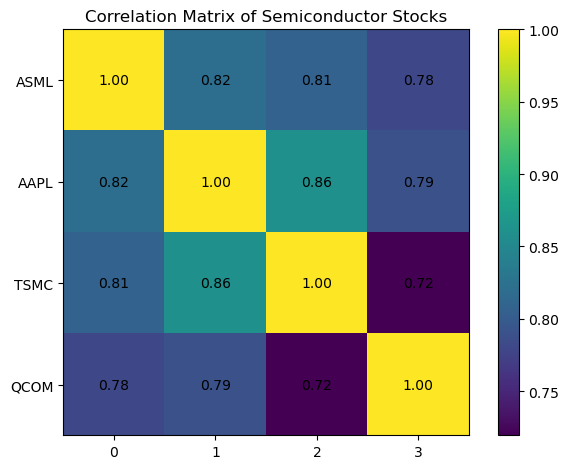

Text(0.5, 1.0, 'Correlation Matrix of Raw Metals')

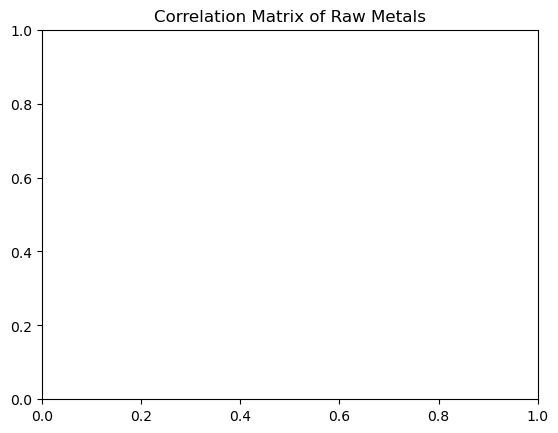

In [13]:
corr_df = pd.DataFrame(
    [
        [1.000000, 0.820968, 0.807154, 0.780001],
        [0.820968, 1.000000, 0.860488, 0.788815],
        [0.807154, 0.860488, 1.000000, 0.719413],
        [0.780001, 0.788815, 0.719413, 1.000000]
    ],
    columns=["ASML", "AAPL", "TSMC", "QCOM"],
    index=["ASML", "AAPL", "TSMC", "QCOM"]
)

plot_correlation_matrix(corr_df, "Correlation Matrix of Semiconductor Stocks")
plt.title("Correlation Matrix of Raw Metals")

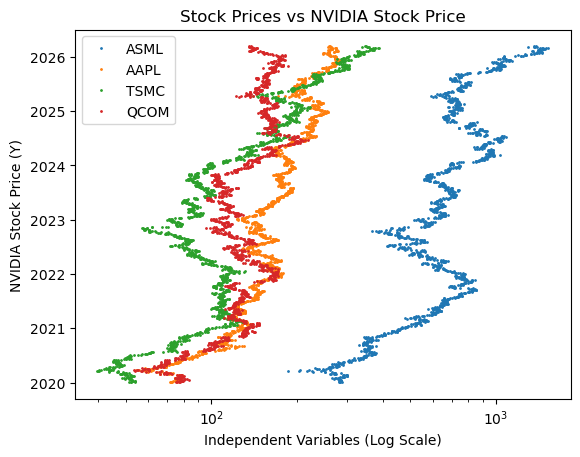

In [14]:
data1_plot = {
    "ASML": asml.history(start="2020-01-01")['Close'].shift(1),
    "AAPL": aapl.history(start="2020-01-01")['Close'].shift(1),
    # "X3": goog.history(start="2020-01-01")['Close'],
    "TSMC": tsmc.history(start="2020-01-01")['Close'].shift(1),
    "QCOM": qcom.history(start="2020-01-01")['Close'].shift(1)
}

plot_data_log(data1_plot)

### MODEL 2: yearly metal production 

Importing data

In [15]:
silver_data = pd.read_excel('./Data/Silver Historical Statistics.xlsx', sheet_name="Silver")
Tin_data = pd.read_excel('./Data/Tin Historical Statistics.xlsx', sheet_name="Tin")
Silicon_data = pd.read_excel('./Data/Silicon Historical Statistics.xlsx', sheet_name="Silicon")
Aluminum_data = pd.read_excel('./Data/Aluminum Historical Statistics.xlsx', sheet_name="Aluminum")
Rare_Earths_data = pd.read_excel('./Data/Rare Earths Historical Statistics.xlsx', sheet_name="Rare earths")
Gold_data = pd.read_excel('./Data/Gold Historical Statistics.xlsx', sheet_name="Gold")

filtered_silver_data = silver_data[(124-20):124]["Unnamed: 11"]
filtered_Tin_data = Tin_data[(124-20):124]["Unnamed: 11"] 
filtered_Silicon_data = Silicon_data[(102-21):101]["Unnamed: 9"] 
filtered_Aluminum_data = Aluminum_data[(124-20):124]["Unnamed: 15"] 
filtered_Rare_Earths_data = Rare_Earths_data[(124-20):124]["Unnamed: 7"] 
filtered_Gold_data = Gold_data[(124-20):124]["Unnamed: 8"]

filtered_Silicon_data

81     3500000
82     3500000
83     3720000
84     4390000
85     4900000
86     5310000
87     5650000
88     6330000
89     6510000
90     6260000
91     6930000
92     7370000
93     7450000
94     7950000
95     7900000
96     7800000
97     7700000
98     7230000
99     8890000
100    8560000
Name: Unnamed: 9, dtype: object

In [16]:
filtered_Gold_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index
filtered_silver_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index
filtered_Tin_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index
filtered_Silicon_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index
filtered_Aluminum_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index
filtered_Rare_Earths_data.index = nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last().index

In [21]:
len(filtered_Aluminum_data), len(filtered_Silicon_data)

(20, 20)

In [17]:
data2 = {
    "Y": nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last(),
    # "X1": filtered_silver_data.astype(float).shift(1),
    # "X2": filtered_Tin_data.astype(float).shift(1),
    "X3": filtered_Silicon_data.astype(float).shift(1),
    # "X4": filtered_Aluminum_data.astype(float).shift(1),
    "X5": filtered_Rare_Earths_data.astype(float).shift(1),
    "X6": filtered_Gold_data.astype(float).shift(1)
}

In [18]:
p_valueTest(data2)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     30.78
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           1.18e-06
Time:                        17:48:33   Log-Likelihood:                -17.745
No. Observations:                  19   AIC:                             43.49
Df Residuals:                      15   BIC:                             47.27
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.6524      1.460     -7.981      0.0

/opt/homebrew/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  res = hypotest_fun_out(*samples, **kwds)


In [19]:
Durbin_Watson_test(data2)

PatsyError: Error evaluating factor: NameError: name 'X1' is not defined
    Y ~ X1+X2+X3
        ^^

In [ ]:
Pagan_test(data2)

Lagrange multiplier statistic: 11.139604471871898
p-value: 0.08415643418109706
f-value: 2.8343623249006447
f p-value: 0.058840689650422176


In [ ]:
Whites_test(data2)

Test Statistic: 19.0
Test Statistic p-value: 0.39182348254493965
F-Statistic: nan
F-Test p-value: nan


In [ ]:
VIF_test(data2)

  Variable         VIF
0    const  702.556778
1       X1   17.446360
2       X2    2.037078
3       X3   28.393788
4       X4   66.044190
5       X5    2.597244
6       X6   10.959539


In [ ]:
corr_df2 = correlation_matrix(data2)

corr_df2

,X1,X2,X3,X4,X5,X6
X1,1.000000,0.642150,0.899768,0.956202,0.500906,0.834021
X2,0.642150,1.000000,0.578023,0.664324,0.543646,0.651947
X3,0.899768,0.578023,1.000000,0.944878,0.623875,0.653180
X4,0.956202,0.664324,0.944878,1.000000,0.648099,0.842747
X5,0.500906,0.543646,0.623875,0.648099,1.000000,0.498845
X6,0.834021,0.651947,0.653180,0.842747,0.498845,1.000000


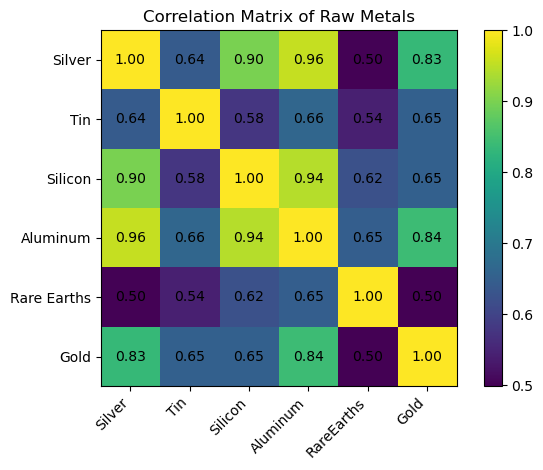

In [ ]:
corr_df2 = pd.DataFrame(
    [
        [1.000000, 0.642150, 0.899768, 0.956202, 0.500906, 0.834021],
        [0.642150, 1.000000, 0.578023, 0.664324, 0.543646, 0.651947],
        [0.899768, 0.578023, 1.000000, 0.944878, 0.623875, 0.653180],
        [0.956202, 0.664324, 0.944878, 1.000000, 0.648099, 0.842747],
        [0.500906, 0.543646, 0.623875, 0.648099, 1.000000, 0.498845],
        [0.834021, 0.651947, 0.653180, 0.842747, 0.498845, 1.000000]
    ],
    columns=["Silver", "Tin", "Silicon", "Aluminum", "RareEarths", "Gold"],
    index=["Silver", "Tin", "Silicon", "Aluminum", "Rare Earths", "Gold"]
)

plot_correlation_matrix_rotate(corr_df2, "Correlation Matrix of Raw Metals")

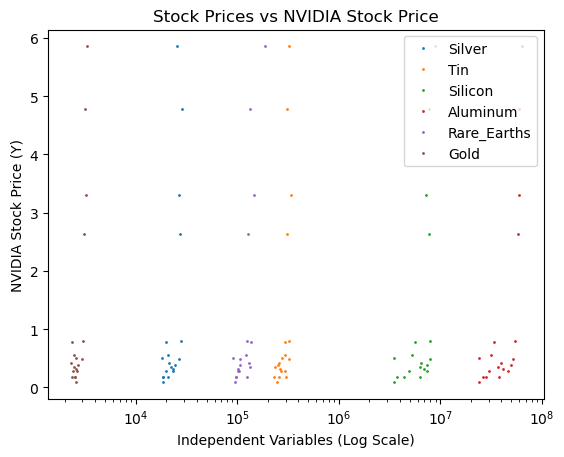

In [ ]:
data2_plot = {
    "Y": nvda.history(start="2000-01-01", end="2020-1-1")['Close'].resample('YE').last(),
    "Silver": filtered_silver_data.astype(float).shift(1),
    "Tin": filtered_Tin_data.astype(float).shift(1),
    "Silicon": filtered_Silicon_data.astype(float).shift(1),
    "Aluminum": filtered_Aluminum_data.astype(float).shift(1),
    "Rare_Earths": filtered_Rare_Earths_data.astype(float).shift(1),
    "Gold": filtered_Gold_data.astype(float).shift(1)
}

plot_data_log_y(data2_plot)

## MODEL 3: Daily metal prices

In [ ]:
data3 = {
    "X1": copper.history(start="2020-01-01")['Close'].shift(1), 
    "X2": gold.history(start="2020-01-01")['Close'].shift(1),
    "X3": silver.history(start="2020-01-01")['Close'].shift(1),
    "X4": platinum.history(start="2020-01-01")['Close'].shift(1), 

    "Y": nvda.history(start="2020-01-01")['Close'], 
}

In [ ]:
Cochrane_Orcutt_test(data3)

Estimated rho: 0.9831
Adjusted R²: 0.0270
Durbin-Watson statistic: 1.9032
rho estimate: 0.0484
z-statistic: 1.8980
p-value: 0.0577


In [ ]:
for i in LRM(data3):
    print(i)

['X1', -1.6401330925358493]
['X2', 0.09168018056842878]
['X3', 1.9668017685809598]
['X4', -0.09282526279580318]


In [ ]:
p_valueTest(data3)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     3409.
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:46:45   Log-Likelihood:                -6714.7
No. Observations:                1542   AIC:                         1.344e+04
Df Residuals:                    1537   BIC:                         1.347e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -110.2915      3.798    -29.043      0.0

In [ ]:
Durbin_Watson_test(data3)

Durbin-Watson statistic: 0.03370680715112057
rho estimate: 0.9831465964244397
z-statistic: 38.55639739179163
p-value: 0.0


In [ ]:
Pagan_test(data3)

Lagrange multiplier statistic: 512.003064820882
p-value: 1.6977855316685642e-109
f-value: 191.00753695272982
f p-value: 5.3715989636112214e-133


In [ ]:
Whites_test(data3)

Test Statistic: 683.2163484054088
Test Statistic p-value: 9.839311911340917e-137
F-Statistic: 86.77317390190773
F-Test p-value: 1.7881858721546374e-182


In [ ]:
VIF_test(data3)

  Variable        VIF
0    const  62.491288
1       X1   2.109996
2       X2   7.038074
3       X3  18.195851
4       X4   8.528261


In [ ]:
correlation_matrix(data3)

,X1,X2,X3,X4
X1,1.000000,0.696300,0.706531,0.676261
X2,0.696300,1.000000,0.910768,0.792748
X3,0.706531,0.910768,1.000000,0.928990
X4,0.676261,0.792748,0.928990,1.000000


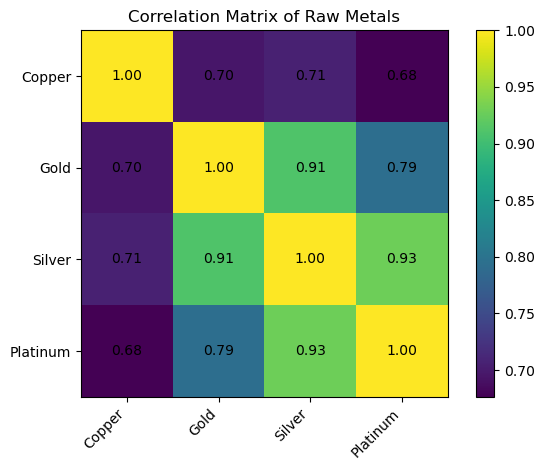

In [ ]:
corr_df3 = pd.DataFrame(
    [
        [1.000000, 0.696300, 0.706531, 0.676261],
        [0.696300, 1.000000, 0.910768, 0.792748],
        [0.706531, 0.910768, 1.000000, 0.928990],
        [0.676261, 0.792748, 0.928990, 1.000000]
    ],
    columns=["Copper", "Gold", "Silver", "Platinum"],
    index=["Copper", "Gold", "Silver", "Platinum"]
)

plot_correlation_matrix_rotate(corr_df3, "Correlation Matrix of Raw Metals")

## MODEL 5: S&P 500

In [ ]:
eqix = yf.Ticker("EQIX")
dlr = yf.Ticker("DLR")

data5 = {
    "Y": nvda.history(start="2020-01-01")['Close'],
    "X1": s_p.history(start="2020-01-01")['Close'].shift(1),
}

In [ ]:
LRM(data5)

[['X1', -0.002303387696067844]]

In [ ]:
Cochrane_Orcutt_test(data5)

Estimated rho: 0.9801
Adjusted R²: 0.0176
Durbin-Watson statistic: 1.8972
rho estimate: 0.0514
z-statistic: 2.0174
p-value: 0.0437


In [ ]:
p_valueTest(data5)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                 1.403e+04
Date:                Tue, 24 Feb 2026   Prob (F-statistic):               0.00
Time:                        09:54:28   Log-Likelihood:                -6696.3
No. Observations:                1542   AIC:                         1.340e+04
Df Residuals:                    1540   BIC:                         1.341e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -182.2870      2.104    -86.640      0.0

In [ ]:
Durbin_Watson_test(data5, True)

Durbin-Watson statistic: 0.03985301541988344
rho estimate: 0.9800734922900582
z-statistic: 38.47334637767192
p-value: 0.0


In [ ]:
Pagan_test(data5)

Lagrange multiplier statistic: 142.0328668189098
p-value: 9.565216760172187e-33
f-value: 156.2398214335991
f p-value: 3.2284409378621454e-34


In [ ]:
Whites_test(data5)

Test Statistic: 369.59188180650483
Test Statistic p-value: 5.548078376110506e-81
F-Statistic: 242.57845765203723
F-Test p-value: 2.6620983960428094e-92


In [ ]:
VIF_test(data5) #probably not needed

  Variable       VIF
0    const  1.001925
1       X1  1.000000


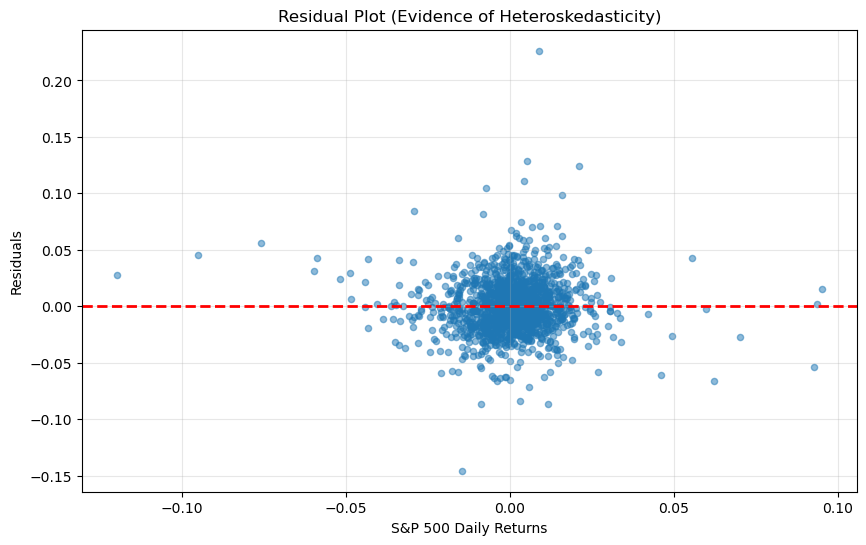

In [ ]:
# Calculate residuals
data5['residuals'] = data5['Y'] - (0.0018 + 1.7839 * data5['X1'])

plt.figure(figsize=(10, 6))
plt.scatter(data5['X1'], data5['residuals'], alpha=0.5, s=20)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('S&P 500 Daily Returns')
plt.ylabel('Residuals')
plt.title('Residual Plot (Evidence of Heteroskedasticity)')
plt.grid(True, alpha=0.3)
plt.show()

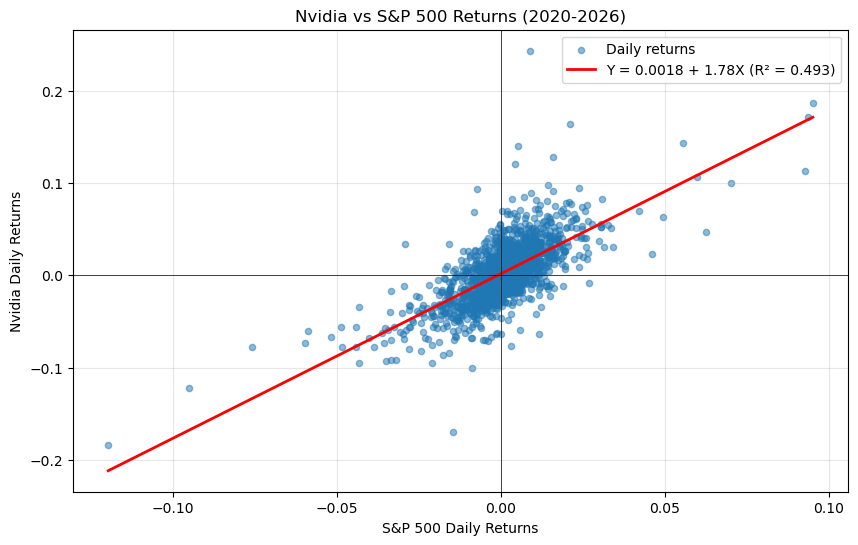

In [ ]:
# Prepare data
df = pd.DataFrame(data5).dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['X1'], df['Y'], alpha=0.5, s=20, label='Daily returns')

# Add regression line
x_line = np.linspace(df['X1'].min(), df['X1'].max(), 100)
y_line = 0.0018 + 1.7839 * x_line  # Using your coefficients
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'Y = 0.0018 + 1.78X (R² = 0.493)')

plt.xlabel('S&P 500 Daily Returns')
plt.ylabel('Nvidia Daily Returns')
plt.title('Nvidia vs S&P 500 Returns (2020-2026)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.show()

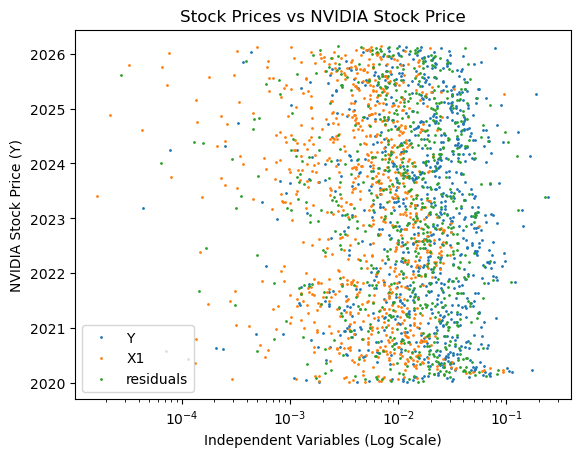

In [ ]:
plot_data_log(data5)

## MODEL 6: Nasdaq

In [ ]:
# nvda_hourly = nvda.history(start="2024-03-01", interval="1h")['Close']
# ndx_hourly = ndx.history(start="2024-03-01", interval="1h")['Close']

# data6 = {
#     "Y": nvda_hourly,
#     "X1": ndx_hourly.shift(1)
# }

data6 = {
    "Y": nvda.history(start="2020-01-01")['Close'],
    "X1": ndx.history(start="2020-01-01")['Close'].shift(1),
}

In [ ]:
df6 = pd.DataFrame(data6).dropna()

df6

,Y,X1
Datetime,,
2024-03-01 11:30:00-05:00,-0.002422,0.002718
2024-03-01 12:30:00-05:00,0.000084,0.001947
2024-03-01 13:30:00-05:00,0.004391,0.002800
2024-03-01 14:30:00-05:00,-0.001625,0.002732
2024-03-01 15:30:00-05:00,0.003598,-0.001231
...,...,...
2026-02-19 15:30:00-05:00,0.005861,-0.000733
2026-02-23 09:30:00-05:00,0.018255,0.002934
2026-02-23 10:30:00-05:00,-0.004304,0.000797


In [ ]:
p_valueTest(data6)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                 1.556e+04
Date:                Tue, 24 Feb 2026   Prob (F-statistic):               0.00
Time:                        09:56:08   Log-Likelihood:                -6624.1
No. Observations:                1542   AIC:                         1.325e+04
Df Residuals:                    1540   BIC:                         1.326e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -134.9732      1.631    -82.741      0.0

In [ ]:
Durbin_Watson_test(data6, True)

Durbin-Watson statistic: 0.04521661587487947
rho estimate: 0.9773916920625603
z-statistic: 38.35561967114973
p-value: 0.0


In [ ]:
Pagan_test(data6)

Lagrange multiplier statistic: 81.89067463786954
p-value: 1.4382631452961575e-19
f-value: 86.37136737075585
f p-value: 4.925162125916281e-20


In [ ]:
Whites_test(data6)

Test Statistic: 131.77042732306623
Test Statistic p-value: 2.4345307689966065e-29
F-Statistic: 71.90130301453293
F-Test p-value: 1.4047178522931803e-30


In [ ]:
VIF_test(data6) # probably not needed

  Variable       VIF
0    const  1.002471
1       X1  1.000000


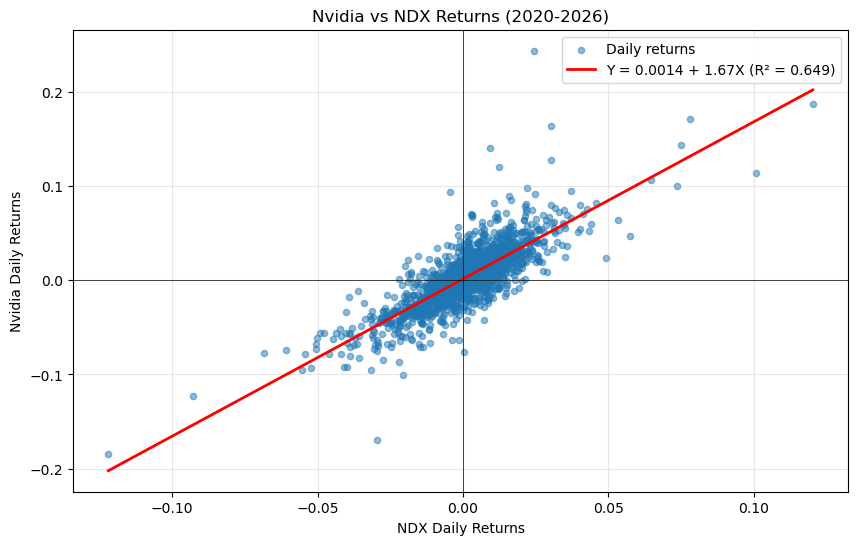

In [ ]:
# Prepare data
df = pd.DataFrame(data6).dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['X1'], df['Y'], alpha=0.5, s=20, label='Daily returns')

# Add regression line
x_line = np.linspace(df['X1'].min(), df['X1'].max(), 100)
y_line = 0.0014 + 1.6695 * x_line  # Using your coefficients
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'Y = 0.0014 + 1.67X (R² = 0.649)')

plt.xlabel('NDX Daily Returns')
plt.ylabel('Nvidia Daily Returns')
plt.title('Nvidia vs NDX Returns (2020-2026)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.show()

## MODEL 8: Metal ETFs 

In [ ]:
data8 = {
    "X1": gold_etf.history(start="2020-01-01")['Close'].shift(1),
    "X2": silver_etf.history(start="2020-01-01")['Close'].shift(1),
    "X3": copper_etf.history(start="2020-01-01")['Close'].shift(1),
    "X4": platinum_etf.history(start="2020-01-01")['Close'].shift(1),
    "X5": uranium_etf.history(start="2020-01-01")['Close'].shift(1),

    "Y": nvda.history(start="2020-01-01")['Close'],
}

In [ ]:
Cochrane_Orcutt_test(data8)

Estimated rho: 0.9754
Adjusted R²: 0.0931
Durbin-Watson statistic: 1.8739
rho estimate: 0.0631
z-statistic: 2.4719
p-value: 0.0134


In [ ]:
p_valueTest(data8)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     3925.
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:59:06   Log-Likelihood:                -6457.7
No. Observations:                1542   AIC:                         1.293e+04
Df Residuals:                    1536   BIC:                         1.296e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -65.5512      3.917    -16.737      0.0

In [ ]:
Durbin_Watson_test(data8)

Durbin-Watson statistic: 0.049067996233341224
rho estimate: 0.9754660018833294
z-statistic: 38.24274619213545
p-value: 0.0


In [ ]:
Pagan_test(data8)

Lagrange multiplier statistic: 321.636300283727
p-value: 2.2257462934847447e-67
f-value: 80.96493813289666
f p-value: 1.4540017629743173e-75


In [ ]:
Whites_test(data8)

Test Statistic: 555.7765367610373
Test Statistic p-value: 5.807270397059094e-105
F-Statistic: 42.85722982280699
F-Test p-value: 6.256328056076342e-132


In [ ]:
VIF_test(data8)

  Variable        VIF
0    const  92.707797
1       X1  10.101272
2       X2  18.696320
3       X3   3.156433
4       X4   8.399320
5       X5   6.421687


In [ ]:
correlation_matrix(data8)

,X1,X2,X3,X4,X5
X1,1.000000,0.907892,0.726390,0.776866,0.880414
X2,0.907892,1.000000,0.719532,0.925128,0.818067
X3,0.726390,0.719532,1.000000,0.666931,0.818781
X4,0.776866,0.925128,0.666931,1.000000,0.729022
X5,0.880414,0.818067,0.818781,0.729022,1.000000


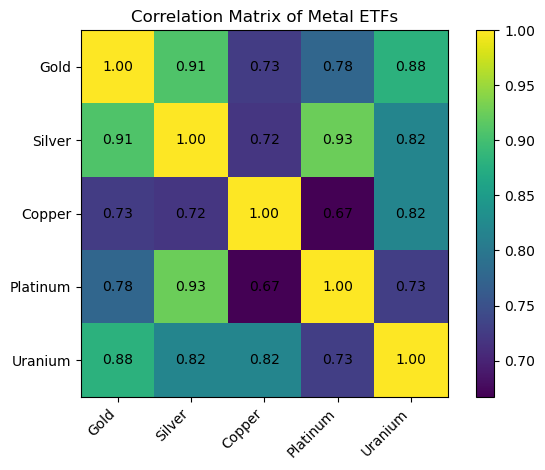

In [ ]:
corr_df2 = pd.DataFrame(
    [
        [1.000000, 0.907892, 0.726390, 0.776866, 0.880414],
        [0.907892, 1.000000, 0.719532, 0.925128, 0.818067],
        [0.726390, 0.719532, 1.000000, 0.666931, 0.818781],
        [0.776866, 0.925128, 0.666931, 1.000000, 0.729022],
        [0.880414, 0.818067, 0.818781, 0.729022, 1.000000]
    ],
    columns=["Gold", "Silver", "Copper", "Platinum", "Uranium"],
    index=["Gold", "Silver", "Copper", "Platinum", "Uranium"]
)

plot_correlation_matrix_rotate(corr_df2, "Correlation Matrix of Metal ETFs")

## MODEL 9: MUDULAR NUCLEAR REACTORS.

In [ ]:
data9 = {
    "X1": nuscale.history(start="2020-01-01")['Close'],
    "X2": oklo.history(start="2020-01-01")['Close'],
    "X3": ge_vernova.history(start="2020-01-01")['Close'],
    "X4": bwx.history(start="2020-01-01")['Close'],
    "X5": nano_nuclear.history(start="2020-01-01")['Close'],

    "Y": nvda.history(start="2020-01-01")['Close'],
}

In [ ]:
Cochrane_Orcutt_test(data9)

Estimated rho: 0.9146
Adjusted R²: 0.4613
Durbin-Watson statistic: 2.0387
rho estimate: -0.0193
z-statistic: -0.4065
p-value: 0.6844


In [ ]:
p_valueTest(data9)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                     882.6
Date:                Mon, 23 Feb 2026   Prob (F-statistic):          2.13e-227
Time:                        09:19:37   Log-Likelihood:                -1621.8
No. Observations:                 448   AIC:                             3256.
Df Residuals:                     442   BIC:                             3280.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         44.2067      3.237     13.655      0.0

In [ ]:
Durbin_Watson_test(data9)

Durbin-Watson statistic: 0.17014852855324392
rho estimate: 0.914925735723378
z-statistic: 19.256959057359275
p-value: 0.0


In [ ]:
Pagan_test(data9)

Lagrange multiplier statistic: 53.70088913451783
p-value: 2.4144578657167586e-10
f-value: 12.039485935110058
f p-value: 6.040909013664697e-11


In [ ]:
Whites_test(data9)

Test Statistic: 136.1062688012444
Test Statistic p-value: 2.7624618101410053e-19
F-Statistic: 9.316855544797052
F-Test p-value: 2.015316163000921e-23


In [ ]:
VIF_test(data9)

  Variable        VIF
0    const  56.744280
1       X1   3.189496
2       X2   8.965379
3       X3   7.428125
4       X4  11.164962
5       X5   5.064814


In [ ]:
correlation_matrix(data9)

,X1,X2,X3,X4,X5
X1,1.000000,0.697380,0.633166,0.560001,0.815652
X2,0.697380,1.000000,0.845907,0.898970,0.825954
X3,0.633166,0.845907,1.000000,0.915093,0.746171
X4,0.560001,0.898970,0.915093,1.000000,0.703722
X5,0.815652,0.825954,0.746171,0.703722,1.000000


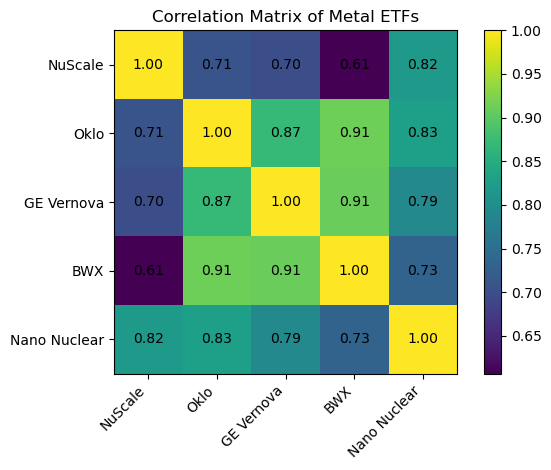

In [ ]:
corr_df9 = pd.DataFrame(
    [
        [1.000000, 0.708873, 0.701035, 0.606506, 0.817787],
        [0.708873, 1.000000, 0.869783, 0.913237, 0.829280],
        [0.701035, 0.869783, 1.000000, 0.909992, 0.791180],
        [0.606506, 0.913237, 0.909992, 1.000000, 0.731993],
        [0.817787, 0.829280, 0.791180, 0.731993, 1.000000]
    ],
    columns=["NuScale", "Oklo", "GE Vernova", "BWX", "Nano Nuclear"],
    index=["NuScale", "Oklo", "GE Vernova", "BWX", "Nano Nuclear"]
)

plot_correlation_matrix_rotate(corr_df9, "Correlation Matrix of Metal ETFs")

## MODEL ULTIMATE

In [ ]:
dataU = {
    "Y": nvda.history(start="2020-01-01")['Close'],
    "X1": asml.history(start="2020-01-01")['Close'],
    "X2": uranium_etf.history(start="2020-01-01")['Close'],
    "X3": ndx.history(start="2020-01-01")['Close']
}

In [ ]:
Cochrane_Orcutt_test(dataU)

Estimated rho: 0.9880
Adjusted R²: 0.4459
Durbin-Watson statistic: 2.0507
rho estimate: -0.0253
z-statistic: -0.9940
p-value: 0.3202


In [ ]:
p_valueTest(dataU)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     7048.
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        09:19:38   Log-Likelihood:                -6409.8
No. Observations:                1543   AIC:                         1.283e+04
Df Residuals:                    1539   BIC:                         1.285e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -121.2532      1.809    -67.037      0.0

In [ ]:
Durbin_Watson_test(dataU)

Durbin-Watson statistic: 0.023835444285772972
rho estimate: 0.9880822778571136
z-statistic: 38.77514855207605
p-value: 0.0


In [ ]:
VIF_test(dataU)

  Variable        VIF
0    const  21.195958
1       X1   4.300712
2       X2   7.764772
3       X3   7.004127


In [ ]:
Pagan_test(dataU)

Lagrange multiplier statistic: 180.86967738129601
p-value: 5.7233864522719645e-39
f-value: 68.11840464591006
f p-value: 2.32304401752431e-41


In [ ]:
Whites_test(dataU)

Test Statistic: 595.2041957395056
Test Statistic p-value: 2.240026784365488e-122
F-Statistic: 106.96725414753097
F-Test p-value: 2.2867001512970226e-155


In [ ]:
correlation_matrix(dataU)

,X1,X2,X3
X1,1.000000,0.865357,0.849451
X2,0.865357,1.000000,0.919664
X3,0.849451,0.919664,1.000000


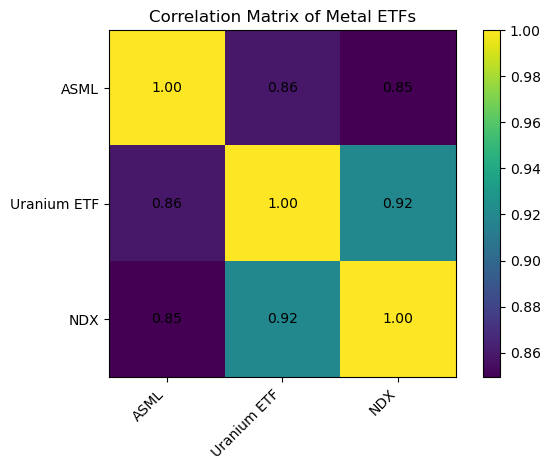

In [ ]:
corr_dfU = pd.DataFrame(
    [
        [1.000000, 0.859099, 0.849275],
        [0.859099, 1.000000, 0.919765],
        [0.849275, 0.919765, 1.000000]
    ],
    columns=["ASML", "Uranium ETF", "NDX"],
    index=["ASML", "Uranium ETF", "NDX"]
)

plot_correlation_matrix_rotate(corr_dfU, "Correlation Matrix of Metal ETFs")

In [ ]:
# Your data dictionary (based on your screenshot)
data = {
    'Y': nvda.history(start='2020-01-01')['Close'],
    'X1': asml.history(start='2020-01-01')['Close'],
    'X2': qcom.history(start='2020-01-01')['Close'],
    'X3': uranium_etf.history(start='2020-01-01')['Close'],
    'X4': ndx.history(start='2020-01-01')['Close']
}

df = pd.DataFrame(data)

# Prepare X and Y
Y = df['Y']
X = df[['X1', 'X2', 'X3', 'X4']]

# Add constant
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(Y, X)
results = model.fit()

# Get Newey-West HAC standard errors
# maxlags=5 is a good starting point for daily data
nw_results = results.get_robustcov_results(cov_type='HAC', maxlags=5)

print("=" * 80)
print("NEWEY-WEST (HAC) STANDARD ERRORS")
print("=" * 80)
print(nw_results.summary())

# You can also access individual values:
print("\nCoefficients with Newey-West Standard Errors:")
print(nw_results.params)
print("\nNewey-West P-values:")
print(nw_results.pvalues)
print("\nNewey-West Confidence Intervals:")
print(nw_results.conf_int())

NEWEY-WEST (HAC) STANDARD ERRORS
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     2009.
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        09:19:40   Log-Likelihood:                -6381.8
No. Observations:                1543   AIC:                         1.277e+04
Df Residuals:                    1538   BIC:                         1.280e+04
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -115.98

In [ ]:
# Replace QCOM with TSMC
data_tsmc = {
    'Y': nvda.history(start='2020-01-01')['Close'],
    'X1': asml.history(start='2020-01-01')['Close'],
    'X2': tsmc.history(start='2020-01-01')['Close'],  # Replace QCOM with TSMC
    'X3': uranium_etf.history(start='2020-01-01')['Close'],
    'X4': ndx.history(start='2020-01-01')['Close']
}

df_tsmc = pd.DataFrame(data_tsmc)

Y = df_tsmc['Y']
X = df_tsmc[['X1', 'X2', 'X3', 'X4']]
X = sm.add_constant(X)

# Fit with Newey-West
model = sm.OLS(Y, X)
results = model.fit()
nw_results = results.get_robustcov_results(cov_type='HAC', maxlags=8)

print(nw_results.summary())

# Check VIFs
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

ValueError: r_matrix performs f_test for using dimensions that are asymptotically non-normal